# Paso 13a — ¿Por qué MedGemma gana en páncreas? (interpretabilidad)

MedGemma (embedding del prompt leakage-safe) añade una ventaja **real y significativa** sobre las 12
features tabulares **solo en páncreas** (`both−tab` = **+0.0386**, IC95% [+0.020, +0.058], p>0 = 1.0).
Este notebook **no recalcula nada**: lee `results/interpret_pancreas.json` (producido por
`scripts/24_pancreas_interpret.py`) y lo dibuja.

La pregunta del paso: *¿esa ventaja es solo estructura contable (conteos, palabras raras, repeticiones)
que el encoder multi-hot tira, o es semántica que solo un LM captura?*

Dos figuras:
- **Figura 1 (test decisivo)** — ¿features de ingeniería cierran la brecha? → mecanismo.
- **Figura 2 (refutación)** — ¿gana donde hay más vocabulario fuera de cobertura (OOV)? → descarta la hipótesis fácil.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = REPO / "results"

data = json.loads((RESULTS / "interpret_pancreas.json").read_text())
print("model:", data["model"], "| pooling:", data["pooling"], "| template:", data["template_id"])
print("tabular vocab:", data["tabular_vocab"])

gap = data["gap_closure_per_cancer"]
cov = data["coverage_per_cancer"]

# short labels for plotting
SHORT = {
    "Pancreatic Cancer": "Pancreas",
    "Breast Cancer": "Breast",
    "Colorectal Cancer": "Colorectal",
    "Non-Small Cell Lung Cancer": "NSCLC",
    "Prostate Cancer": "Prostate",
}
list(gap.keys())

model: medgemma15 | pooling: mean | template: ctx_v1
tabular vocab: {'mutations_top_k': 50, 'treatments_top_k': 30}


['Breast Cancer',
 'Colorectal Cancer',
 'Non-Small Cell Lung Cancer',
 'Pancreatic Cancer',
 'Prostate Cancer']

## Figura 1 — El test decisivo (dumbbell / forest plot)

Un renglón por tumor, ordenados por la ventaja de MedGemma (`both−tab`). En cada renglón **dos puntos**
con su IC95% como barra:
- **ingeniería** (`enriched−tab`): cuánto recupera el tabular si le agregas conteos / OOV / repeticiones.
- **MedGemma** (`both−tab`): cuánto aporta el embedding del LM.

La línea vertical en **0** = "no mejora". Si la barra de un punto **no toca el 0**, la mejora es sólida.

Lectura: en **páncreas** el punto de MedGemma está lejos a la derecha y su IC **no cruza 0**, mientras el de
ingeniería se queda corto pegado al 0 → *los conteos no alcanzan, el LM aporta algo extra*. En **colorrectal**
los dos puntos casi coinciden → *ahí los conteos lo explican todo*.

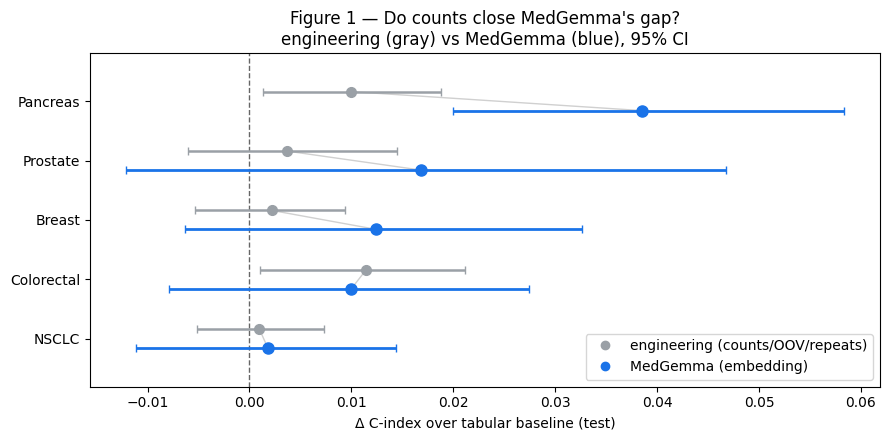

In [2]:
# order cancers by MedGemma advantage (both-tab point), largest at top
order = sorted(gap.keys(), key=lambda c: gap[c]["both_minus_tab"]["point"], reverse=True)
y = np.arange(len(order))[::-1]  # top = largest

def err(d):
    return [[d["point"] - d["ci_low"]], [d["ci_high"] - d["point"]]]

fig, ax = plt.subplots(figsize=(9, 4.5))
OFF = 0.16
C_ENG, C_LM = "#9aa0a6", "#1a73e8"  # gray (engineering) vs blue (MedGemma)

for yi, c in zip(y, order):
    de, db = gap[c]["enriched_minus_tab"], gap[c]["both_minus_tab"]
    ax.errorbar(de["point"], yi + OFF, xerr=err(de), fmt="o", color=C_ENG,
                capsize=3, ms=7, lw=1.8, zorder=3)
    ax.errorbar(db["point"], yi - OFF, xerr=err(db), fmt="o", color=C_LM,
                capsize=3, ms=8, lw=2.0, zorder=3)
    # connector line between the two points (the "dumbbell")
    ax.plot([de["point"], db["point"]], [yi + OFF, yi - OFF], color="#d0d0d0",
            lw=1.0, zorder=1)

ax.axvline(0, color="k", lw=1, ls="--", alpha=0.6)
ax.set_yticks(y)
ax.set_yticklabels([SHORT[c] for c in order])
ax.set_xlabel("Δ C-index over tabular baseline (test)")
ax.set_title("Figure 1 — Do counts close MedGemma's gap?\n"
             "engineering (gray) vs MedGemma (blue), 95% CI")

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker="o", color=C_ENG, lw=0, label="engineering (counts/OOV/repeats)"),
    Line2D([0], [0], marker="o", color=C_LM, lw=0, label="MedGemma (embedding)"),
], loc="lower right", frameon=True)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

In [3]:
# supporting table: % of MedGemma's gap reproduced by the engineered counts
print(f"{'tumor':12s} {'engineering':>22s} {'MedGemma':>22s} {'% closed':>10s}")
for c in order:
    de, db = gap[c]["enriched_minus_tab"], gap[c]["both_minus_tab"]
    frac = de["point"] / db["point"] * 100 if abs(db["point"]) > 1e-9 else float("nan")
    es = f"{de['point']:+.4f} [{de['ci_low']:+.3f},{de['ci_high']:+.3f}]"
    bs = f"{db['point']:+.4f} [{db['ci_low']:+.3f},{db['ci_high']:+.3f}]"
    print(f"{SHORT[c]:12s} {es:>22s} {bs:>22s} {frac:9.0f}%")

tumor                   engineering               MedGemma   % closed
Pancreas     +0.0100 [+0.001,+0.019] +0.0386 [+0.020,+0.058]        26%
Prostate     +0.0037 [-0.006,+0.014] +0.0168 [-0.012,+0.047]        22%
Breast       +0.0022 [-0.005,+0.009] +0.0125 [-0.006,+0.033]        18%
Colorectal   +0.0114 [+0.001,+0.021] +0.0100 [-0.008,+0.027]       115%
NSCLC        +0.0010 [-0.005,+0.007] +0.0018 [-0.011,+0.014]        54%


**Interpretación (Figura 1).** En páncreas los conteos reproducen solo **~26%** de la ventaja
(ingeniería +0.0100 vs MedGemma +0.0386); el ~**74% restante es semántico** — combinaciones de
mutaciones/tratamientos con significado clínico que ningún feature contable captura. El contraste con
**colorrectal (115%, los conteos explican el 100%)** es nítido. Esto descarta la alternativa que
desinflaba el proyecto ("agrega features de conteo y ahórrate el LM") y **justifica empíricamente el
fine-tuning**: el residual semántico es el territorio natural de un LM survival-aware.

*Caveat honesto:* los features de ingeniería son un conjunto manual (otro más rico podría cerrar algo
más) y los IC por tumor son anchos; pero la dirección y el contraste 26% vs 115% son sólidos.

## Figura 2 — La refutación de la hipótesis fácil (scatter)

Hipótesis simple: *"MedGemma gana en páncreas porque el texto guarda mutaciones raras (fuera del
vocabulario top-K) que el tabular tira."* Si fuera cierta, **más OOV ⇒ más ventaja** (los puntos caerían
en una diagonal ascendente).

- eje **X** = fracción de tokens de mutación fuera de vocabulario (`mutations.frac_tokens_oov`).
- eje **Y** = ventaja de MedGemma (`both−tab.point`).

Páncreas aparece como **outlier arriba-a-la-izquierda**: el de **menor OOV** y a la vez **mayor ganancia**
→ rompe la diagonal y desmonta la explicación fácil.

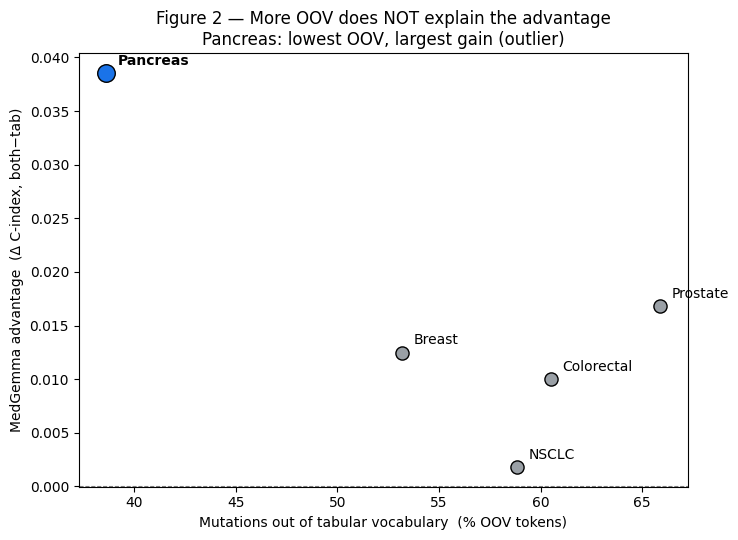

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for c in gap.keys():
    x = cov[c]["mutations"]["frac_tokens_oov"] * 100
    yv = gap[c]["both_minus_tab"]["point"]
    is_panc = c == "Pancreatic Cancer"
    ax.scatter(x, yv, s=160 if is_panc else 90,
               color="#1a73e8" if is_panc else "#9aa0a6",
               edgecolor="k", zorder=3)
    ax.annotate(SHORT[c], (x, yv), textcoords="offset points",
                xytext=(8, 6), fontsize=10,
                fontweight="bold" if is_panc else "normal")

ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Mutations out of tabular vocabulary  (% OOV tokens)")
ax.set_ylabel("MedGemma advantage  (Δ C-index, both−tab)")
ax.set_title("Figure 2 — More OOV does NOT explain the advantage\n"
             "Pancreas: lowest OOV, largest gain (outlier)")
plt.tight_layout()
plt.show()

### Alternativa (más legible para el paper): barras agrupadas A/B

Las 5 columnas de la tabla A/B por tumor. Muestra que páncreas tampoco destaca en longitud/repetición de
tratamientos — no es estructura contable obvia.

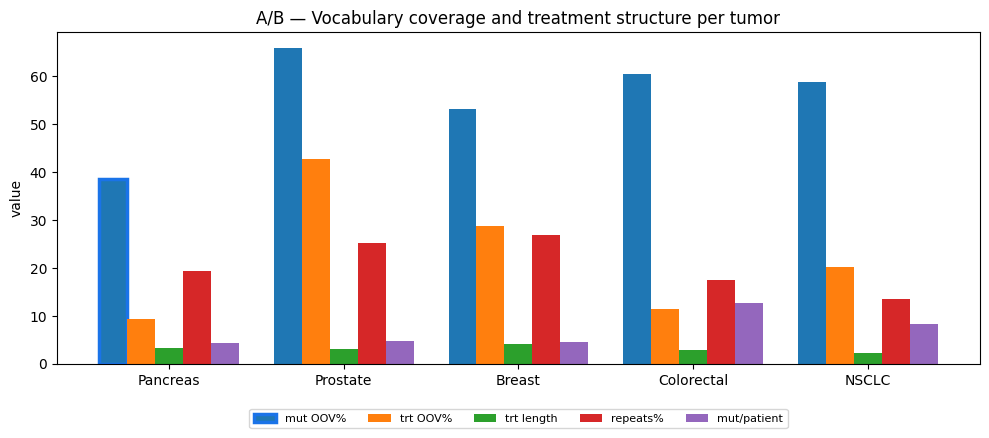

In [5]:
order2 = sorted(gap.keys(), key=lambda c: gap[c]["both_minus_tab"]["point"], reverse=True)
metrics = {
    "mut OOV%":   lambda c: cov[c]["mutations"]["frac_tokens_oov"] * 100,
    "trt OOV%":   lambda c: cov[c]["treatments"]["frac_tokens_oov"] * 100,
    "trt length": lambda c: cov[c]["treatments"]["mean_tokens_per_patient"],
    "repeats%":   lambda c: cov[c]["treatments"]["pct_patients_with_repeat"] * 100,
    "mut/patient": lambda c: cov[c]["mutations"]["mean_tokens_per_patient"],
}
labels = [SHORT[c] for c in order2]
x = np.arange(len(order2))
w = 0.16
fig, ax = plt.subplots(figsize=(10, 4.5))
for i, (name, fn) in enumerate(metrics.items()):
    vals = [fn(c) for c in order2]
    bars = ax.bar(x + (i - 2) * w, vals, w, label=name)
    if name == "mut OOV%":  # highlight pancreas on the OOV bar
        for c, b in zip(order2, bars):
            if c == "Pancreatic Cancer":
                b.set_edgecolor("#1a73e8"); b.set_linewidth(2.5)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("value")
ax.set_title("A/B — Vocabulary coverage and treatment structure per tumor")
ax.legend(ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()

## Conclusión defendible para el paper

1. **El LM aporta algo que los conteos no** (Figura 1): ~74% de la ventaja de MedGemma en páncreas es
   irreproducible con features de ingeniería; en colorrectal los conteos la explican entera.
2. **Y no es por palabras raras** (Figura 2): páncreas es el tumor *mejor* cubierto por el vocabulario
   tabular, no el peor.

→ MedGemma captura **estructura semántica** (combinaciones mutación/tratamiento con sentido clínico) —
exactamente lo que un LM aporta como extractor. Esto motiva el fine-tuning como paso natural, no como
apuesta a ciegas, y centra la narrativa del paper en páncreas, donde la evidencia es más fuerte.